In [ ]:
!pip install -q "protobuf==6.31.1" importlib_resources array_record "etils[epath,epy]" promise toml simple_parsing dm-tree

import tensorflow as tf, tensorflow_datasets as tfds
print('TF', tf.__version__, '| tfds', tfds.__version__)
print('GPU:', tf.config.list_physical_devices('GPU') or 'NONE -> Runtime > Change runtime type > T4')
_ = tfds.load('mnist', split='train[:1%]', as_supervised=True)
print('tfds pipeline OK')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.1/321.1 kB 5.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.31.1 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.31.1 which is incompatible.


/usr/local/lib/python3.13/dist-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_handle.proto. Please update the gencode to avoid compatibility violations in the next r

TF 2.20.0 | tfds 4.9.10
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

...

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.B1ZVB7_3.0.1/mnist-train.tfrecord-[0-9][0-9][0-9][0-9][0-…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.B1ZVB7_3.0.1/mnist-test.tfrecord-[0-9][0-9][0-9][0-9][0-9…

Dataset mnist downloaded and prepared to /root/tensorflow_datasets/mnist/3.0.1. Subsequent calls will reuse this data.
tfds pipeline OK


In [ ]:
# ===================== CELL 1 — imports, plot style, helpers =====================
import os, time, gc, warnings
warnings.filterwarnings('ignore')
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

SEED, IMG_SIZE, N_CLASSES = 42, 224, 37
AUTOTUNE = tf.data.AUTOTUNE
PLOTS, CACHE = 'plots', '/content/exp5_cache'
os.makedirs(PLOTS, exist_ok=True); os.makedirs(CACHE, exist_ok=True)
tf.keras.utils.set_random_seed(SEED)

print('TensorFlow', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU') or 'NONE -> Runtime > Change runtime type > T4 GPU')

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 600, 'font.size': 11,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelweight': 'bold', 'axes.titleweight': 'bold', 'axes.titlesize': 12,
    'legend.frameon': False, 'lines.linewidth': 2.0, 'lines.markersize': 6,
})
C = ['#0B6E4F', '#C1495C', '#2E5EAA', '#E08A1E', '#6B4E9B']

def save(fig, name):
    fig.tight_layout()
    fig.savefig(f'{PLOTS}/{name}.png', dpi=600, bbox_inches='tight')
    plt.show()

def table(title, headers, rows):
    rows = [[str(c) for c in r] for r in rows]
    w = [max(len(str(h)), *(len(r[i]) for r in rows)) for i, h in enumerate(headers)]
    head = '  '.join(str(h).ljust(w[i]) for i, h in enumerate(headers))
    print(f'\n{title}')
    print('-' * len(head)); print(head); print('-' * len(head))
    for r in rows:
        print('  '.join(r[i].ljust(w[i]) for i in range(len(headers))))
    print('-' * len(head))

TensorFlow 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ===================== CELL 2 — Section 3: dataset and splits =====================
(raw_trainval, raw_test), info = tfds.load(
    'oxford_iiit_pet', split=['train', 'test'], as_supervised=True, with_info=True)

CLASS_NAMES = [n.replace('_', ' ') for n in info.features['label'].names]
N_TRAIN = info.splits['train'].num_examples

rng = np.random.RandomState(SEED)
is_val = np.zeros(N_TRAIN, bool)
is_val[rng.permutation(N_TRAIN)[:int(0.2 * N_TRAIN)]] = True
val_lookup = tf.constant(is_val)

def _keep_val(i, xy):   return val_lookup[i]
def _keep_train(i, xy): return tf.logical_not(val_lookup[i])
def _drop_index(i, xy): return xy

_enum = raw_trainval.enumerate()
raw_val = _enum.filter(_keep_val).map(_drop_index)
raw_tr  = _enum.filter(_keep_train).map(_drop_index)

def prep(img, lab):
    img = tf.image.resize(tf.cast(img, tf.float32), (IMG_SIZE, IMG_SIZE))
    return tf.keras.applications.mobilenet_v2.preprocess_input(img), lab

print(f'Classes: {N_CLASSES}   train+val: {N_TRAIN} (val {is_val.sum()})   '
      f'test: {info.splits["test"].num_examples}')

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.HBRPOI_4.0.0/oxford_iiit_pet-train.tfrecord-[0-…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.HBRPOI_4.0.0/oxford_iiit_pet-test.tfrecord-[0-9…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.
Classes: 37   train+val: 3680 (val 736)   test: 3669


In [ ]:
# ===================== CELL 3 — Section 4: MobileNetV2 =====================
base = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet', pooling='avg')
base.trainable = False
BASE_PARAMS = base.count_params()

print(f'MobileNetV2 base: {BASE_PARAMS:,} parameters, {len(base.layers)} layers, '
      f'output feature vector = {base.output_shape[-1]}-dim')

std = lambda K, Ci, Co: K * K * Ci * Co
sep = lambda K, Ci, Co: K * K * Ci + Ci * Co
table('Standard convolution vs depthwise separable convolution (weights)',
      ['Kernel', 'C_in', 'C_out', 'Standard', 'Depthwise sep.', 'Saving'],
      [(K, Ci, Co, f'{std(K,Ci,Co):,}', f'{sep(K,Ci,Co):,}', f'{std(K,Ci,Co)/sep(K,Ci,Co):.1f}x')
       for K, Ci, Co in [(3, 32, 64), (3, 128, 256), (3, 512, 512)]])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 base: 2,257,984 parameters, 155 layers, output feature vector = 1280-dim

Standard convolution vs depthwise separable convolution (weights)
------------------------------------------------------
Kernel  C_in  C_out  Standard   Depthwise sep.  Saving
------------------------------------------------------
3       32    64     18,432     2,336           7.9x  
3       128   256    294,912    33,920          8.7x  
3       512   512    2,359,296  266,752         8.8x  
------------------------------------------------------


In [ ]:
# ===================== CELL 4 — cache frozen features =====================
FEAT = f'{CACHE}/features.npz'

if os.path.exists(FEAT):
    _d = np.load(FEAT)
    Xtr, ytr, Xva, yva, Xte, yte = (_d['Xtr'], _d['ytr'], _d['Xva'],
                                    _d['yva'], _d['Xte'], _d['yte'])
    print('loaded cached features')
else:
    def embed(raw, bs=32):
        d = raw.map(prep, num_parallel_calls=2).batch(bs).prefetch(1)
        Xs, ys = [], []
        for xb, yb in d:
            Xs.append(base(xb, training=False).numpy())
            ys.append(yb.numpy())
        return np.concatenate(Xs).astype('float32'), np.concatenate(ys).astype('int32')

    t0 = time.time()
    Xtr, ytr = embed(raw_tr);   gc.collect()
    Xva, yva = embed(raw_val);  gc.collect()
    Xte, yte = embed(raw_test); gc.collect()
    np.savez_compressed(FEAT, Xtr=Xtr, ytr=ytr, Xva=Xva, yva=yva, Xte=Xte, yte=yte)
    print(f'extracted and cached ({time.time()-t0:.0f}s)')

Xfull = np.concatenate([Xtr, Xva])
yfull = np.concatenate([ytr, yva])
gc.collect()
print(f'train {Xtr.shape}  val {Xva.shape}  test {Xte.shape}')

extracted and cached (93s)
train (2944, 1280)  val (736, 1280)  test (3669, 1280)


In [ ]:
# ===================== CELL 5 — head builder and training helper =====================
INITS = {
    'Zero':          tf.keras.initializers.Zeros(),
    'Random':        tf.keras.initializers.RandomNormal(stddev=0.05, seed=SEED),
    'Xavier/Glorot': tf.keras.initializers.GlorotUniform(seed=SEED),
    'He':            tf.keras.initializers.HeNormal(seed=SEED),
}

def optimizer(name, lr):
    return {'SGD':      tf.keras.optimizers.SGD(lr),
            'Momentum': tf.keras.optimizers.SGD(lr, momentum=0.9),
            'RMSProp':  tf.keras.optimizers.RMSprop(lr),
            'Adam':     tf.keras.optimizers.Adam(lr)}[name]

def build_head(init='Xavier/Glorot', l2=0.0, dropout=0.0, bn=False, opt='Adam', lr=1e-3, units=256):
    reg = tf.keras.regularizers.l2(l2) if l2 > 0 else None
    ki = INITS[init]
    L = [tf.keras.layers.Input(shape=(1280,)),
         tf.keras.layers.Dense(units, kernel_initializer=ki, kernel_regularizer=reg, use_bias=not bn)]
    if bn:
        L.append(tf.keras.layers.BatchNormalization())
    L.append(tf.keras.layers.Activation('relu'))
    if dropout > 0:
        L.append(tf.keras.layers.Dropout(dropout, seed=SEED))
    L.append(tf.keras.layers.Dense(N_CLASSES, kernel_initializer=ki,
                                   kernel_regularizer=reg, activation='softmax'))
    m = tf.keras.Sequential(L)
    m.compile(optimizer=optimizer(opt, lr), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

def train_head(cfg, epochs=20, data=None):
    Xa, ya, Xb, yb = data if data else (Xtr, ytr, Xva, yva)
    cfg = dict(cfg); bs = cfg.pop('bs', 32)
    tf.keras.utils.set_random_seed(SEED)
    m = build_head(**cfg)
    t = time.time()
    h = m.fit(Xa, ya, validation_data=(Xb, yb), epochs=epochs, batch_size=bs, verbose=0)
    return m, h.history, time.time() - t

BASE = dict(init='Xavier/Glorot', l2=0.0, dropout=0.0, bn=False, opt='Adam', lr=1e-3, bs=32)
ep  = lambda h: range(1, len(h['loss']) + 1)
pct = lambda v: 100 * np.array(v)

score = lambda h: 100 * float(np.mean(h['val_accuracy'][-5:]))

def epochs_to(h, thresh):
    v = np.array(h['val_accuracy'])
    return int(np.argmax(v >= thresh)) + 1 if (v >= thresh).any() else len(v) + 1

Zero            final train loss  3.6102   mean val acc (last 5)   1.22%   (10.0s)
Random          final train loss  0.0010   mean val acc (last 5)  91.68%   (9.1s)
Xavier/Glorot   final train loss  0.0009   mean val acc (last 5)  91.39%   (8.9s)
He              final train loss  0.0009   mean val acc (last 5)  91.11%   (9.8s)

Initialization — convergence speed (threshold = 87.3% val accuracy)
------------------------------------------------------------------------------------------------------
Initialization  Epochs to threshold  Final train loss  Mean val acc (last 5) %  Val acc SD (last 10) %
------------------------------------------------------------------------------------------------------
Zero            21                   3.6102            1.22                     0.00                  
Random          1                    0.0010            91.68                    0.33                  
Xavier/Glorot   1                    0.0009            91.39                    0.22   

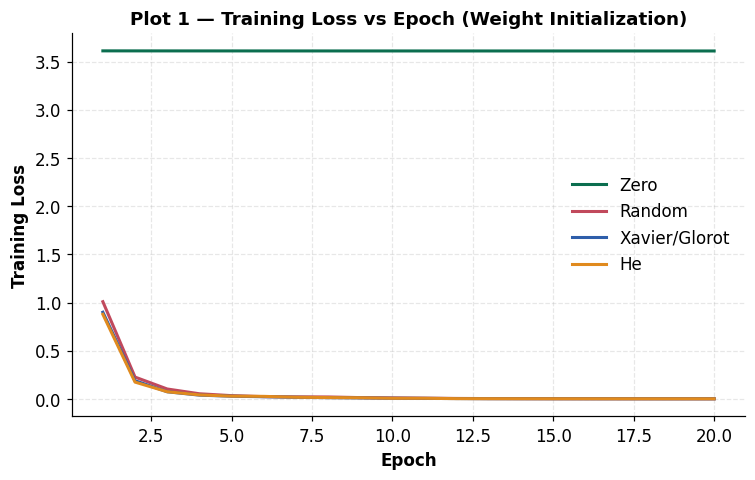

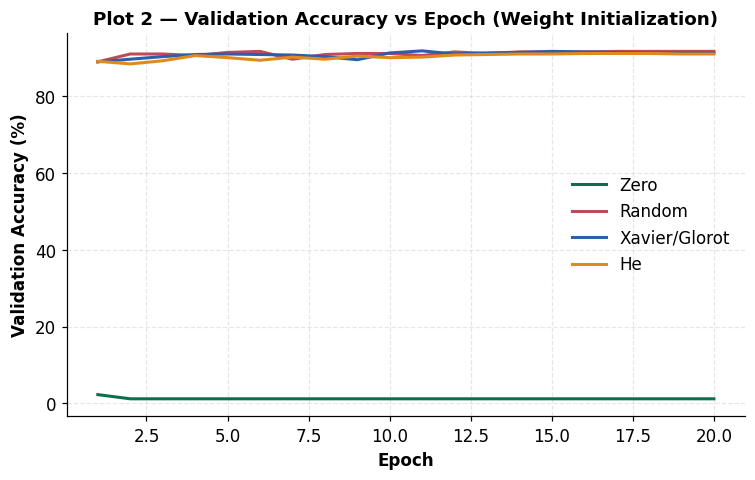

In [ ]:
# ===================== CELL 6 — Section 5: weight initialization (Plots 1, 2) =====================
init_res = {}
for name in INITS:
    _, h, t = train_head({**BASE, 'init': name}, epochs=20)
    init_res[name] = h
    print(f'{name:15s} final train loss {h["loss"][-1]:7.4f}   '
          f'mean val acc (last 5) {score(h):6.2f}%   ({t:.1f}s)')

INIT_THRESH = 0.95 * max(max(h['val_accuracy']) for h in init_res.values())

table(f'Initialization — convergence speed (threshold = {100*INIT_THRESH:.1f}% val accuracy)',
      ['Initialization', 'Epochs to threshold', 'Final train loss',
       'Mean val acc (last 5) %', 'Val acc SD (last 10) %'],
      [[k, epochs_to(h, INIT_THRESH), f'{h["loss"][-1]:.4f}', f'{score(h):.2f}',
        f'{100*np.std(h["val_accuracy"][-10:]):.2f}'] for k, h in init_res.items()])

fig, ax = plt.subplots(figsize=(7, 4.5))
for i, (k, h) in enumerate(init_res.items()):
    ax.plot(ep(h), h['loss'], color=C[i], label=k)
ax.set_xlabel('Epoch'); ax.set_ylabel('Training Loss')
ax.set_title('Plot 1 — Training Loss vs Epoch (Weight Initialization)')
ax.legend()
save(fig, 'plot01_init_train_loss')

fig, ax = plt.subplots(figsize=(7, 4.5))
for i, (k, h) in enumerate(init_res.items()):
    ax.plot(ep(h), pct(h['val_accuracy']), color=C[i], label=k)
ax.set_xlabel('Epoch'); ax.set_ylabel('Validation Accuracy (%)')
ax.set_title('Plot 2 — Validation Accuracy vs Epoch (Weight Initialization)')
ax.legend()
save(fig, 'plot02_init_val_acc')


Generalization gap after 40 epochs
-------------------------------------------------------------------------------------------
Regularization     Train Acc %  Val Acc %  Gap %  Mean val (last 5) %  Min val loss @ epoch
-------------------------------------------------------------------------------------------
No Regularization  100.00       91.58      8.42   91.58                6                   
L2 (1e-3)          100.00       92.66      7.34   92.77                40                  
Dropout (0.5)      98.85        91.44      7.40   91.30                4                   
Batch Norm         100.00       91.85      8.15   91.90                7                   
-------------------------------------------------------------------------------------------


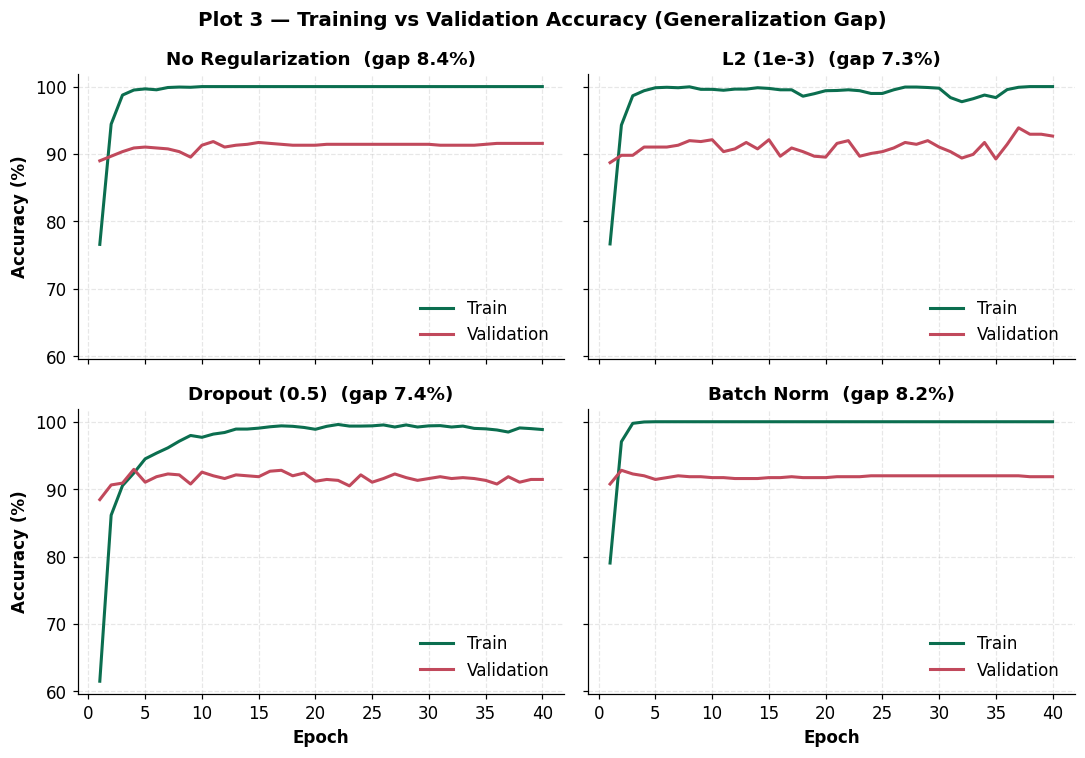

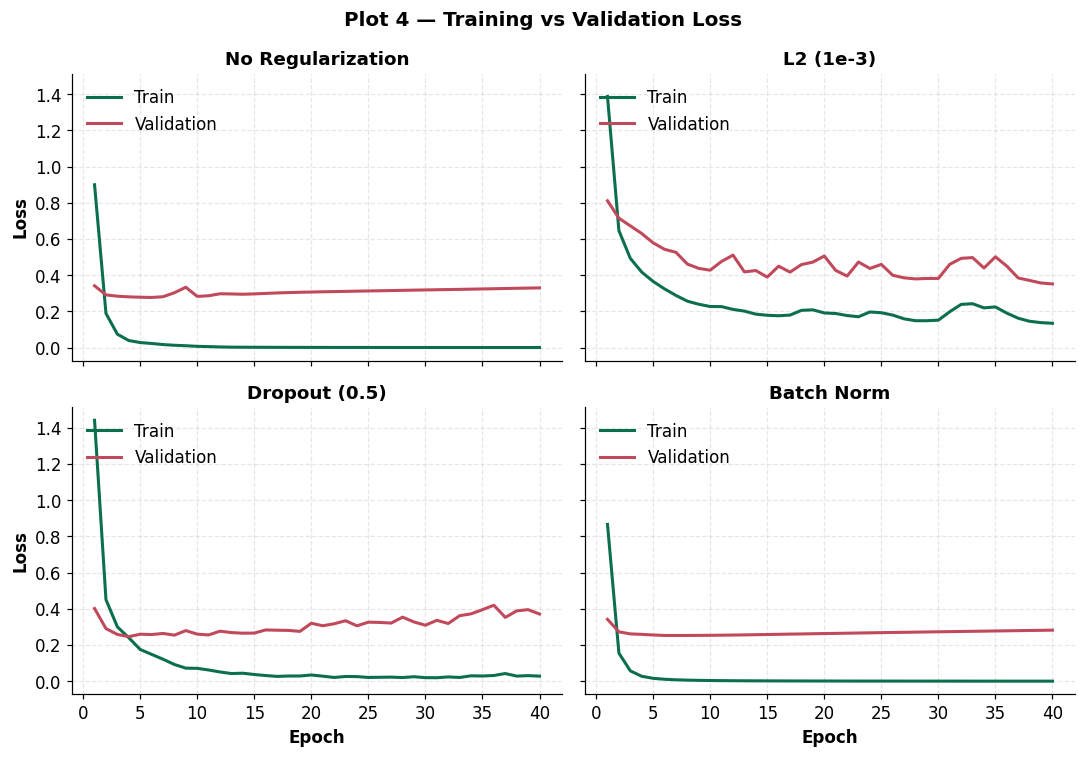

In [ ]:
# ===================== CELL 7 — Section 6: regularization (Plots 3, 4) =====================
REGS = {'No Regularization': {},
        'L2 (1e-3)':         {'l2': 1e-3},
        'Dropout (0.5)':     {'dropout': 0.5},
        'Batch Norm':        {'bn': True}}

reg_res, reg_time = {}, {}
for k, v in REGS.items():
    _, h, t = train_head({**BASE, **v}, epochs=40)
    reg_res[k], reg_time[k] = h, t

table('Generalization gap after 40 epochs',
      ['Regularization', 'Train Acc %', 'Val Acc %', 'Gap %',
       'Mean val (last 5) %', 'Min val loss @ epoch'],
      [[k, f'{100*h["accuracy"][-1]:.2f}', f'{100*h["val_accuracy"][-1]:.2f}',
        f'{100*(h["accuracy"][-1]-h["val_accuracy"][-1]):.2f}', f'{score(h):.2f}',
        int(np.argmin(h['val_loss'])) + 1] for k, h in reg_res.items()])

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
for ax, (k, h) in zip(axes.ravel(), reg_res.items()):
    ax.plot(ep(h), pct(h['accuracy']), color=C[0], label='Train')
    ax.plot(ep(h), pct(h['val_accuracy']), color=C[1], label='Validation')
    ax.set_title(f'{k}  (gap {100*(h["accuracy"][-1]-h["val_accuracy"][-1]):.1f}%)')
    ax.legend(loc='lower right')
for ax in axes[-1]:
    ax.set_xlabel('Epoch')
for ax in axes[:, 0]:
    ax.set_ylabel('Accuracy (%)')
fig.suptitle('Plot 3 — Training vs Validation Accuracy (Generalization Gap)',
             fontweight='bold', fontsize=13)
save(fig, 'plot03_reg_accuracy')

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
for ax, (k, h) in zip(axes.ravel(), reg_res.items()):
    ax.plot(ep(h), h['loss'], color=C[0], label='Train')
    ax.plot(ep(h), h['val_loss'], color=C[1], label='Validation')
    ax.set_title(k)
    ax.legend(loc='upper left')
for ax in axes[-1]:
    ax.set_xlabel('Epoch')
for ax in axes[:, 0]:
    ax.set_ylabel('Loss')
fig.suptitle('Plot 4 — Training vs Validation Loss', fontweight='bold', fontsize=13)
save(fig, 'plot04_reg_loss')

mu_B = 5.000   sigma^2_B = 5.000   sqrt(sigma^2_B) = 2.236
x_hat = [-1.342 -0.447  0.447  1.342]   (manual: [-1.342, -0.447, 0.447, 1.342])
mean(x_hat) = 0.000, std(x_hat) = 1.000  ->  zero-centred, unit scale
With gamma=1 and beta=0 the output equals x_hat. gamma and beta are learnable, so the network
can rescale or shift — including recovering the identity mapping — if that helps.


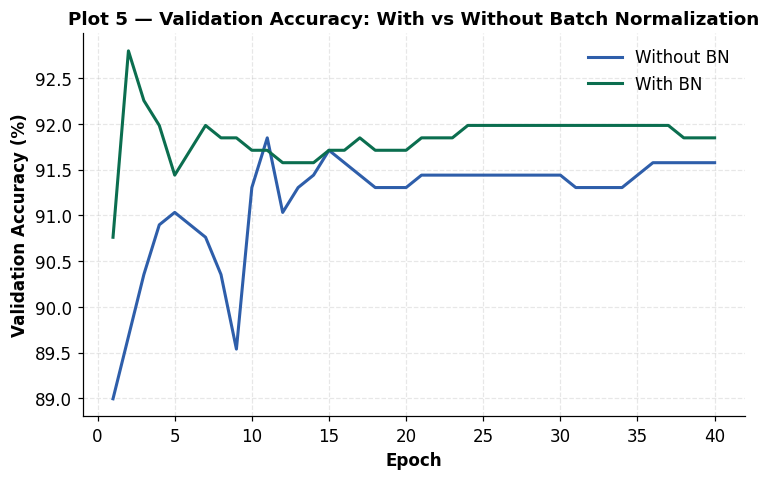

In [ ]:
# ===================== CELL 8 — Section 7: Batch Normalization (Plot 5) =====================
x = np.array([2., 4., 6., 8.])
mu, var = x.mean(), x.var()
xhat = (x - mu) / np.sqrt(var + 1e-8)
print(f'mu_B = {mu:.3f}   sigma^2_B = {var:.3f}   sqrt(sigma^2_B) = {np.sqrt(var):.3f}')
print('x_hat =', np.round(xhat, 3), '  (manual: [-1.342, -0.447, 0.447, 1.342])')
print(f'mean(x_hat) = {xhat.mean():.3f}, std(x_hat) = {xhat.std():.3f}  ->  zero-centred, unit scale')
print('With gamma=1 and beta=0 the output equals x_hat. gamma and beta are learnable, so the network')
print('can rescale or shift — including recovering the identity mapping — if that helps.')

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(ep(reg_res['No Regularization']), pct(reg_res['No Regularization']['val_accuracy']),
        color=C[2], label='Without BN')
ax.plot(ep(reg_res['Batch Norm']), pct(reg_res['Batch Norm']['val_accuracy']),
        color=C[0], label='With BN')
ax.set_xlabel('Epoch'); ax.set_ylabel('Validation Accuracy (%)')
ax.set_title('Plot 5 — Validation Accuracy: With vs Without Batch Normalization')
ax.legend()
save(fig, 'plot05_batchnorm')


Optimizer comparison (Section 8 table)
---------------------------------------------------------------------------------------------
Optimizer  Final Loss  Best Val. Accuracy %  Mean val (last 5) %  Epoch to Converge  Time (s)
---------------------------------------------------------------------------------------------
SGD        0.7338      86.01                 85.00                25                 10.7    
Momentum   0.0883      92.53                 91.63                9                  11.1    
RMSProp    0.0001      93.07                 92.34                9                  10.7    
Adam       0.0006      91.85                 91.44                11                 11.0    
---------------------------------------------------------------------------------------------


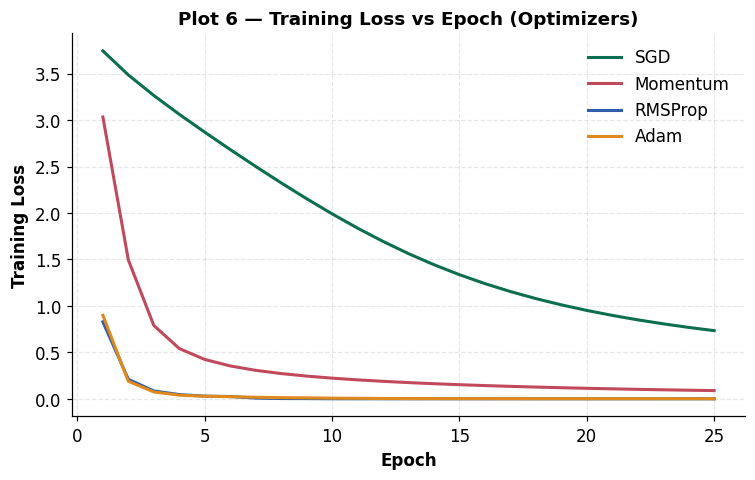

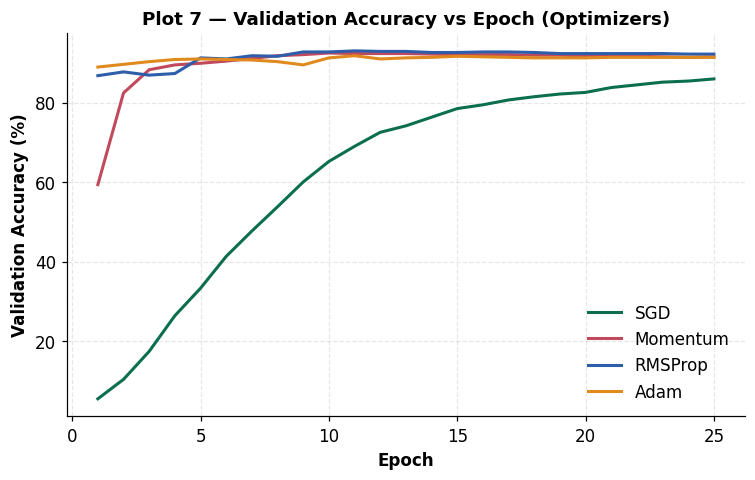

In [ ]:
# ===================== CELL 9 — Section 8: optimizers (Plots 6, 7) =====================
opt_res = {}
for o in ['SGD', 'Momentum', 'RMSProp', 'Adam']:
    _, h, t = train_head({**BASE, 'opt': o}, epochs=25)
    opt_res[o] = (h, t)

def converge_epoch(v, tol=0.005):
    return int(np.argmax(np.array(v) >= max(v) - tol)) + 1

table('Optimizer comparison (Section 8 table)',
      ['Optimizer', 'Final Loss', 'Best Val. Accuracy %', 'Mean val (last 5) %',
       'Epoch to Converge', 'Time (s)'],
      [[o, f'{h["loss"][-1]:.4f}', f'{100*max(h["val_accuracy"]):.2f}', f'{score(h):.2f}',
        converge_epoch(h['val_accuracy']), f'{t:.1f}'] for o, (h, t) in opt_res.items()])

fig, ax = plt.subplots(figsize=(7, 4.5))
for i, (o, (h, _)) in enumerate(opt_res.items()):
    ax.plot(ep(h), h['loss'], color=C[i], label=o)
ax.set_xlabel('Epoch'); ax.set_ylabel('Training Loss')
ax.set_title('Plot 6 — Training Loss vs Epoch (Optimizers)')
ax.legend()
save(fig, 'plot06_opt_loss')

fig, ax = plt.subplots(figsize=(7, 4.5))
for i, (o, (h, _)) in enumerate(opt_res.items()):
    ax.plot(ep(h), pct(h['val_accuracy']), color=C[i], label=o)
ax.set_xlabel('Epoch'); ax.set_ylabel('Validation Accuracy (%)')
ax.set_title('Plot 7 — Validation Accuracy vs Epoch (Optimizers)')
ax.legend()
save(fig, 'plot07_opt_acc')

In [ ]:
# ===================== CELL 10 — Section 9a: convolution output size =====================
conv_out = lambda N, K, P, S: (N + 2 * P - K) // S + 1
table('Convolution output size   O = floor((N + 2P - K) / S) + 1',
      ['Input N', 'Kernel K', 'Padding P', 'Stride S', 'Output O', 'Comment'],
      [[224, 3, 1, 1, conv_out(224, 3, 1, 1), 'same padding, size preserved'],
       [224, 3, 0, 2, conv_out(224, 3, 0, 2), 'stride 2, downsamples ~2x'],
       [112, 5, 2, 1, conv_out(112, 5, 2, 1), 'larger kernel, same padding'],
       [56,  2, 0, 2, conv_out(56, 2, 0, 2),  '2x2 pooling, stride 2']])


Convolution output size   O = floor((N + 2P - K) / S) + 1
------------------------------------------------------------------------------
Input N  Kernel K  Padding P  Stride S  Output O  Comment                     
------------------------------------------------------------------------------
224      3         1          1         224       same padding, size preserved
224      3         0          2         111       stride 2, downsamples ~2x   
112      5         2          1         112       larger kernel, same padding 
56       2         0          2         28        2x2 pooling, stride 2       
------------------------------------------------------------------------------



Hyperparameter sweeps — mean validation accuracy over last 5 epochs, one variable at a time
--------------------------------------
Hyperparameter  Value   Val Accuracy %
--------------------------------------
Learning rate   0.01    86.98         
Learning rate   0.001   91.39         
Learning rate   0.0001  92.26         
Learning rate   1e-05   85.33         
Batch size      16      91.82         
Batch size      32      91.39         
Batch size      64      91.71         
Dropout rate    0       91.39         
Dropout rate    0.25    91.49         
Dropout rate    0.5     92.20         
--------------------------------------


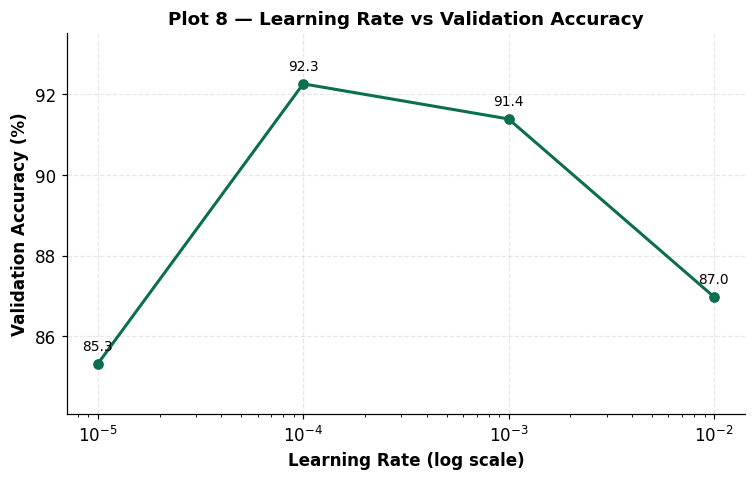

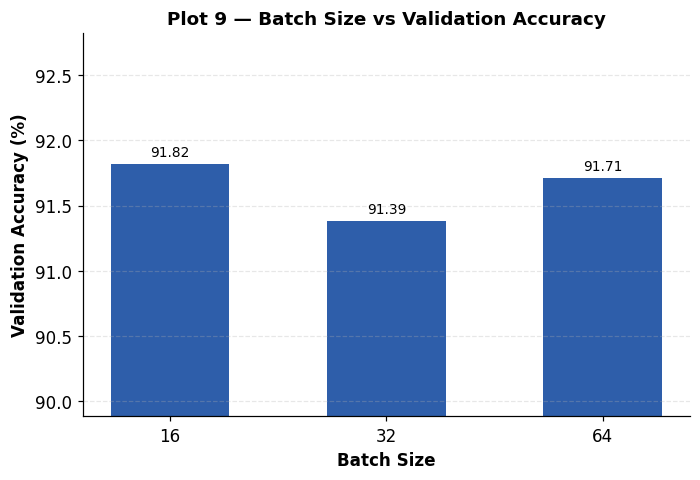

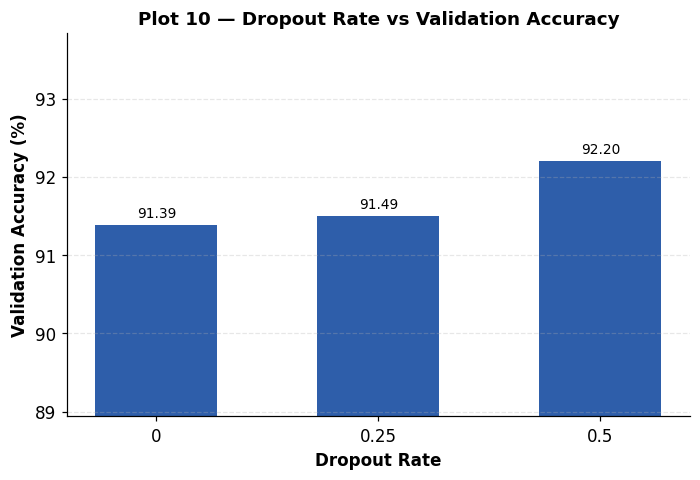

In [ ]:
# ===================== CELL 11 — Section 9b: hyperparameter sweeps (Plots 8, 9, 10) ============
LRS, BSS, DOS = [1e-2, 1e-3, 1e-4, 1e-5], [16, 32, 64], [0.0, 0.25, 0.5]

lr_res = {lr: score(train_head({**BASE, 'lr': lr},     epochs=20)[1]) for lr in LRS}
bs_res = {bs: score(train_head({**BASE, 'bs': bs},     epochs=20)[1]) for bs in BSS}
do_res = {d:  score(train_head({**BASE, 'dropout': d}, epochs=20)[1]) for d in DOS}

table('Hyperparameter sweeps — mean validation accuracy over last 5 epochs, one variable at a time',
      ['Hyperparameter', 'Value', 'Val Accuracy %'],
      [['Learning rate', f'{k:g}', f'{v:.2f}'] for k, v in lr_res.items()] +
      [['Batch size', k, f'{v:.2f}'] for k, v in bs_res.items()] +
      [['Dropout rate', f'{k:g}', f'{v:.2f}'] for k, v in do_res.items()])

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.semilogx(list(lr_res), list(lr_res.values()), 'o-', color=C[0])
for k, v in lr_res.items():
    ax.annotate(f'{v:.1f}', (k, v), textcoords='offset points', xytext=(0, 9), ha='center', fontsize=9)
ax.set_xlabel('Learning Rate (log scale)'); ax.set_ylabel('Validation Accuracy (%)')
ax.set_title('Plot 8 — Learning Rate vs Validation Accuracy')
ax.margins(y=0.18)
save(fig, 'plot08_lr')

def bar_plot(d, xlabel, title, fname, fmt='{}'):
    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    b = ax.bar([fmt.format(k) for k in d], list(d.values()), color=C[2], width=0.55)
    ax.bar_label(b, fmt='%.2f', padding=3, fontsize=9)
    lo, hi = min(d.values()), max(d.values())
    ax.set_ylim(lo - 3 * max(hi - lo, 0.5), hi + 2 * max(hi - lo, 0.5))
    ax.set_xlabel(xlabel); ax.set_ylabel('Validation Accuracy (%)'); ax.set_title(title)
    ax.grid(axis='x', visible=False)
    save(fig, fname)

bar_plot(bs_res, 'Batch Size', 'Plot 9 — Batch Size vs Validation Accuracy', 'plot09_batchsize')
bar_plot(do_res, 'Dropout Rate', 'Plot 10 — Dropout Rate vs Validation Accuracy', 'plot10_dropout', '{:g}')

In [ ]:
# ===================== CELL 12 — Section 10: transfer learning =====================
def make_ds(raw, bs=32, shuffle=False):
    d = raw.map(prep, num_parallel_calls=2)
    if shuffle:
        d = d.shuffle(256, seed=SEED)
    return d.batch(bs).prefetch(1)

ds_tr, ds_va, ds_te = make_ds(raw_tr, shuffle=True), make_ds(raw_val), make_ds(raw_test)

tf.keras.utils.set_random_seed(SEED)
base_ft = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet', pooling='avg')
base_ft.trainable = False
inp = tf.keras.Input((IMG_SIZE, IMG_SIZE, 3))
z = base_ft(inp, training=False)
z = tf.keras.layers.Dense(256, activation='relu', kernel_initializer='he_normal')(z)
z = tf.keras.layers.Dropout(0.3, seed=SEED)(z)
model = tf.keras.Model(inp, tf.keras.layers.Dense(N_CLASSES, activation='softmax')(z))
model.compile(tf.keras.optimizers.Adam(1e-3), 'sparse_categorical_crossentropy', metrics=['accuracy'])

WARM, EXTRA = 8, 8

t0 = time.time()
h_warm = model.fit(ds_tr, validation_data=ds_va, epochs=WARM, verbose=1).history
t_warm = time.time() - t0
model.save_weights('warm.weights.h5')
HEAD_ONLY_PARAMS = sum(int(np.prod(w.shape)) for w in model.trainable_weights)

t0 = time.time()
hA = model.fit(ds_tr, validation_data=ds_va, epochs=WARM + EXTRA, initial_epoch=WARM, verbose=1).history
t_fe = t_warm + (time.time() - t0)
acc_fe = model.evaluate(ds_te, verbose=0)[1] * 100

model.load_weights('warm.weights.h5')
base_ft.trainable = True
for i, l in enumerate(base_ft.layers):
    l.trainable = (i >= 100) and not isinstance(l, tf.keras.layers.BatchNormalization)
model.compile(tf.keras.optimizers.Adam(1e-5), 'sparse_categorical_crossentropy', metrics=['accuracy'])
print(f'Trainable parameters after unfreezing: '
      f'{sum(int(np.prod(w.shape)) for w in model.trainable_weights):,}')
t0 = time.time()
hB = model.fit(ds_tr, validation_data=ds_va, epochs=WARM + EXTRA, initial_epoch=WARM, verbose=1).history
t_ft = t_warm + (time.time() - t0)
acc_ft = model.evaluate(ds_te, verbose=0)[1] * 100

fe = {k: h_warm[k] + hA[k] for k in h_warm}
ft = {k: h_warm[k] + hB[k] for k in h_warm}
print(f'\nCase A feature extraction: test {acc_fe:.2f}%  ({t_fe:.0f}s incl. warm-up)')
print(f'Case B fine-tuning       : test {acc_ft:.2f}%  ({t_ft:.0f}s incl. warm-up)')

Epoch 1/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 44s 254ms/step - accuracy: 0.6827 - loss: 1.1712 - val_accuracy: 0.8750 - val_loss: 0.3808
Epoch 2/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 186ms/step - accuracy: 0.8991 - loss: 0.3098 - val_accuracy: 0.9035 - val_loss: 0.2808
Epoch 3/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 187ms/step - accuracy: 0.9463 - loss: 0.1669 - val_accuracy: 0.9062 - val_loss: 0.2648
Epoch 4/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 187ms/step - accuracy: 0.9548 - loss: 0.1374 - val_accuracy: 0.9062 - val_loss: 0.2818
Epoch 5/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 195ms/step - accuracy: 0.9762 - loss: 0.0893 - val_accuracy: 0.9144 - val_loss: 0.2788
Epoch 6/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 205ms/step - accuracy: 0.9837 - loss: 0.0651 - val_accuracy: 0.9158 - val_loss: 0.2561
Epoch 7/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 202ms/step - accuracy: 0.9861 - loss: 0.0520 - val_accuracy: 0.9130 - val_loss: 0.2578
Epoch 8/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 200ms/step - accuracy: 0.9891 - loss: 0.0427 - val_accuracy: 0.

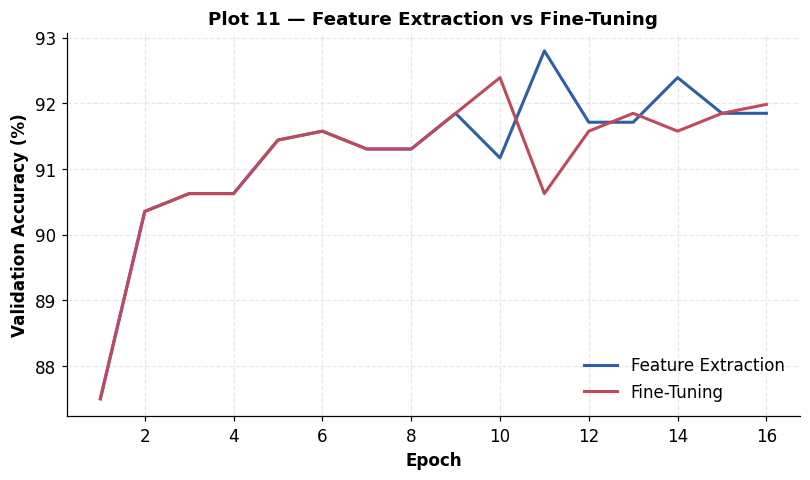

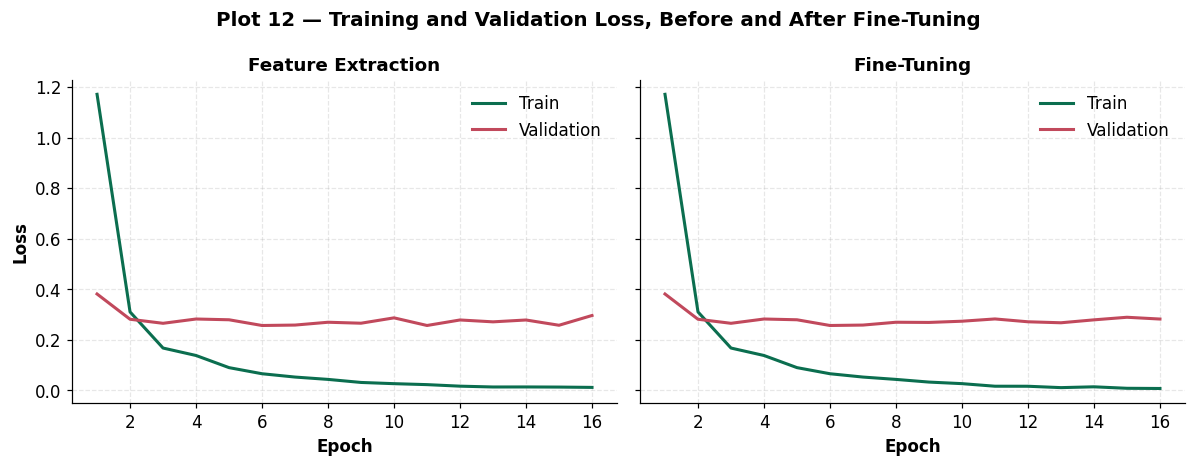

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(ep(fe), pct(fe['val_accuracy']), color=C[2], label='Feature Extraction')
ax.plot(ep(ft), pct(ft['val_accuracy']), color=C[1], label='Fine-Tuning')
ax.set_xlabel('Epoch'); ax.set_ylabel('Validation Accuracy (%)')
ax.set_title('Plot 11 — Feature Extraction vs Fine-Tuning')
ax.legend(loc='lower right')
save(fig, 'plot11_fe_vs_ft')

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3), sharey=True)
for ax, (h, name) in zip(axes, [(fe, 'Feature Extraction'), (ft, 'Fine-Tuning')]):
    ax.plot(ep(h), h['loss'], color=C[0], label='Train')
    ax.plot(ep(h), h['val_loss'], color=C[1], label='Validation')
    ax.set_xlabel('Epoch'); ax.set_title(name); ax.legend()
axes[0].set_ylabel('Loss')
fig.suptitle('Plot 12 — Training and Validation Loss, Before and After Fine-Tuning',
             fontweight='bold', fontsize=13)
save(fig, 'plot12_ft_loss')

lr=0.0001, unfrozen from layer 100: val 90.22%  (2,177,061 trainable, 134s)
lr=1e-05, unfrozen from layer 100: val 92.12%  (2,177,061 trainable, 127s)
lr=0.0001, unfrozen from layer 140: val 89.95%  (1,370,085 trainable, 111s)
lr=1e-05, unfrozen from layer 140: val 92.26%  (1,370,085 trainable, 113s)

Fine-tuning hyperparameters (Section 9, rows 5 and 6)
--------------------------------------------------------------------------------
Fine-tune LR     Unfrozen from layer  Trainable params  Val Accuracy %  Time (s)
--------------------------------------------------------------------------------
- (frozen base)  Case A               337,445           91.30           178     
0.0001           100                  2,177,061         90.22           134     
1e-05            100                  2,177,061         92.12           127     
0.0001           140                  1,370,085         89.95           111     
1e-05            140                  1,370,085         92.26           113 

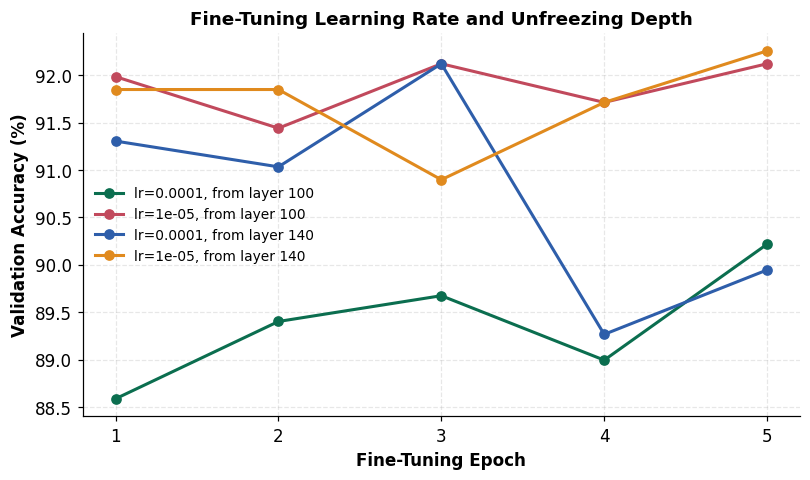


Best fine-tuning config (selected on VALIDATION): lr=1e-05, unfrozen from layer 140
Test accuracy 89.37%  (310s incl. warm-up)


In [ ]:
# ===================== CELL 14 — Section 9c: fine-tuning LR and frozen layers =====================
FT_GRID = [(1e-4, 100), (1e-5, 100), (1e-4, 140), (1e-5, 140)]
ft_grid, FT_EPOCHS = {}, 5

for lr, cut in FT_GRID:
    tf.keras.utils.set_random_seed(SEED)
    model.load_weights('warm.weights.h5')
    base_ft.trainable = True
    for i, l in enumerate(base_ft.layers):
        l.trainable = (i >= cut) and not isinstance(l, tf.keras.layers.BatchNormalization)
    ntr = sum(int(np.prod(w.shape)) for w in model.trainable_weights)
    model.compile(tf.keras.optimizers.Adam(lr), 'sparse_categorical_crossentropy', metrics=['accuracy'])
    t0 = time.time()
    h = model.fit(ds_tr, validation_data=ds_va, epochs=FT_EPOCHS, verbose=0).history
    ft_grid[(lr, cut)] = (h, time.time() - t0, ntr)
    print(f'lr={lr:g}, unfrozen from layer {cut:3d}: val {100*h["val_accuracy"][-1]:.2f}%  '
          f'({ntr:,} trainable, {time.time()-t0:.0f}s)')

table('Fine-tuning hyperparameters (Section 9, rows 5 and 6)',
      ['Fine-tune LR', 'Unfrozen from layer', 'Trainable params', 'Val Accuracy %', 'Time (s)'],
      [['- (frozen base)', 'Case A', f'{HEAD_ONLY_PARAMS:,}',
        f'{100*h_warm["val_accuracy"][-1]:.2f}', f'{t_warm:.0f}']] +
      [[f'{lr:g}', cut, f'{n:,}', f'{100*h["val_accuracy"][-1]:.2f}', f'{t:.0f}']
       for (lr, cut), (h, t, n) in ft_grid.items()])

fig, ax = plt.subplots(figsize=(7.5, 4.5))
for i, ((lr, cut), (h, _, _)) in enumerate(ft_grid.items()):
    ax.plot(range(1, FT_EPOCHS + 1), pct(h['val_accuracy']), color=C[i % len(C)],
            marker='o', label=f'lr={lr:g}, from layer {cut}')
ax.set_xlabel('Fine-Tuning Epoch'); ax.set_ylabel('Validation Accuracy (%)')
ax.set_title('Fine-Tuning Learning Rate and Unfreezing Depth')
ax.set_xticks(range(1, FT_EPOCHS + 1))
ax.legend(fontsize=9)
save(fig, 'plot17_ft_grid')

BEST_FT = max(ft_grid, key=lambda k: ft_grid[k][0]['val_accuracy'][-1])
tf.keras.utils.set_random_seed(SEED)
model.load_weights('warm.weights.h5')
base_ft.trainable = True
for i, l in enumerate(base_ft.layers):
    l.trainable = (i >= BEST_FT[1]) and not isinstance(l, tf.keras.layers.BatchNormalization)
model.compile(tf.keras.optimizers.Adam(BEST_FT[0]), 'sparse_categorical_crossentropy',
              metrics=['accuracy'])
t0 = time.time()
model.fit(ds_tr, validation_data=ds_va, epochs=FT_EPOCHS, verbose=0)
t_ft_best = t_warm + (time.time() - t0)
acc_ft_best = model.evaluate(ds_te, verbose=0)[1] * 100
print(f'\nBest fine-tuning config (selected on VALIDATION): lr={BEST_FT[0]:g}, '
      f'unfrozen from layer {BEST_FT[1]}')
print(f'Test accuracy {acc_ft_best:.2f}%  ({t_ft_best:.0f}s incl. warm-up)')

Best init (fastest convergence): Random
Best regularization: L2 (1e-3) | best optimizer: RMSProp
Best lr: 0.0001 | best batch size: 16 | best dropout: 0.5

Running 5-fold cross-validation...
  C1 Baseline              91.96 +/- 1.03 %  (57s)
  C2 Best Init + Reg       89.92 +/- 1.45 %  (59s)
  C3 + Best Optimizer      88.97 +/- 0.78 %  (54s)
  C4 Fully Tuned           91.47 +/- 0.80 %  (94s)

5-Fold Cross-Validation (Section 11 table)
----------------------------------------------------------------------
Config               F1     F2     F3     F4     F5     Mean +/- SD   
----------------------------------------------------------------------
C1 Baseline          93.07  91.17  93.34  91.17  91.03  91.96 +/- 1.03
C2 Best Init + Reg   91.71  91.03  87.50  89.54  89.81  89.92 +/- 1.45
C3 + Best Optimizer  89.81  88.99  88.72  87.64  89.67  88.97 +/- 0.78
C4 Fully Tuned       92.93  91.30  91.44  91.17  90.49  91.47 +/- 0.80
----------------------------------------------------------------

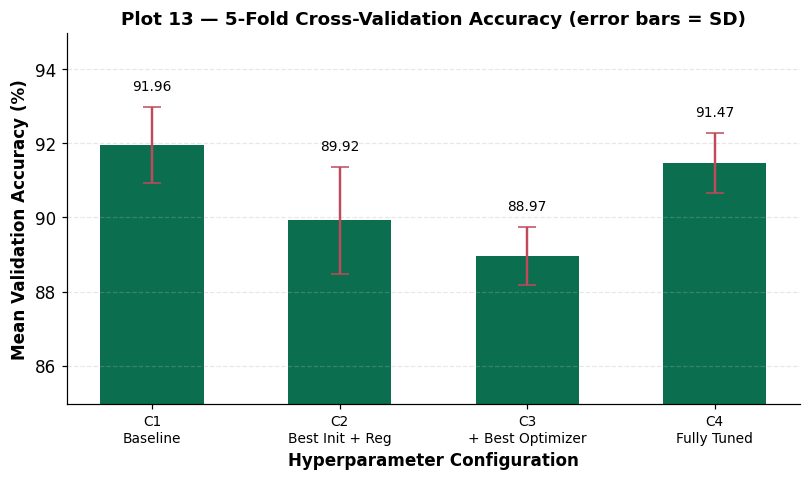


Selected by cross-validation: C1 Baseline
  {'init': 'Xavier/Glorot', 'l2': 0.0, 'dropout': 0.0, 'bn': False, 'opt': 'Adam', 'lr': 0.001, 'bs': 32}
  Margin over runner-up (C4 Fully Tuned): 0.49 %  |  its own SD: 1.03 %
  A margin smaller than the SD means the configurations are statistically indistinguishable.


In [ ]:
# ===================== CELL 15 — Section 11: 5-fold cross-validation (Plot 13) =====================
best_init = min(init_res, key=lambda k: (epochs_to(init_res[k], INIT_THRESH), -score(init_res[k])))
best_reg  = max(reg_res,  key=lambda k: score(reg_res[k]))
best_opt  = max(opt_res,  key=lambda k: score(opt_res[k][0]))
best_lr   = max(lr_res, key=lr_res.get)
best_bs   = max(bs_res, key=bs_res.get)
best_do   = max(do_res, key=do_res.get)
print(f'Best init (fastest convergence): {best_init}')
print(f'Best regularization: {best_reg} | best optimizer: {best_opt}')
print(f'Best lr: {best_lr:g} | best batch size: {best_bs} | best dropout: {best_do:g}')

CFG_INIT  = {**BASE, 'init': best_init}
CFG_REG   = {**BASE, **REGS[best_reg]}
CFG_OPT   = {**BASE, 'init': best_init, **REGS[best_reg], 'opt': best_opt}
CFG_TUNED = {**CFG_OPT, 'lr': best_lr, 'bs': best_bs, 'dropout': best_do}

CONFIGS = {'C1 Baseline': BASE,
           'C2 Best Init + Reg': {**CFG_INIT, **REGS[best_reg]},
           'C3 + Best Optimizer': CFG_OPT,
           'C4 Fully Tuned': CFG_TUNED}

def run_cv(cfg, k=5, epochs=25):
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=SEED)
    accs, t0 = [], time.time()
    for tr_i, va_i in skf.split(Xfull, yfull):
        _, h, _ = train_head(cfg, epochs=epochs,
                             data=(Xfull[tr_i], yfull[tr_i], Xfull[va_i], yfull[va_i]))
        accs.append(h['val_accuracy'][-1] * 100)
    return np.array(accs), time.time() - t0

CV, _cache = {}, {}
def get_cv(name, cfg):
    key = repr(sorted(cfg.items()))
    if key not in _cache:
        _cache[key] = run_cv(cfg)
    CV[name] = _cache[key]
    print(f'  {name:24s} {CV[name][0].mean():.2f} +/- {CV[name][0].std():.2f} %  ({CV[name][1]:.0f}s)')
    return CV[name]

print('\nRunning 5-fold cross-validation...')
for n, c in CONFIGS.items():
    get_cv(n, c)

table('5-Fold Cross-Validation (Section 11 table)',
      ['Config', 'F1', 'F2', 'F3', 'F4', 'F5', 'Mean +/- SD'],
      [[n] + [f'{a:.2f}' for a in CV[n][0]] + [f'{CV[n][0].mean():.2f} +/- {CV[n][0].std():.2f}']
       for n in CONFIGS])

fig, ax = plt.subplots(figsize=(7.5, 4.5))
names = list(CONFIGS)
means = [CV[n][0].mean() for n in names]
sds   = [CV[n][0].std() for n in names]
b = ax.bar(range(len(names)), means, yerr=sds, capsize=6, color=C[0], width=0.55,
           error_kw=dict(ecolor=C[1], lw=1.6))
ax.bar_label(b, fmt='%.2f', padding=9, fontsize=9)
ax.set_xticks(range(len(names)))
ax.set_xticklabels([n.replace(' ', '\n', 1) for n in names], fontsize=9)
ax.set_ylim(min(means) - 4, max(means) + 3)
ax.set_xlabel('Hyperparameter Configuration'); ax.set_ylabel('Mean Validation Accuracy (%)')
ax.set_title('Plot 13 — 5-Fold Cross-Validation Accuracy (error bars = SD)')
ax.grid(axis='x', visible=False)
save(fig, 'plot13_cv')

BEST_NAME = max(CONFIGS, key=lambda n: CV[n][0].mean())
BEST_CFG = CONFIGS[BEST_NAME]
_runner = max((n for n in CONFIGS if n != BEST_NAME), key=lambda n: CV[n][0].mean())
_gap = CV[BEST_NAME][0].mean() - CV[_runner][0].mean()
print(f'\nSelected by cross-validation: {BEST_NAME}')
print(f'  {BEST_CFG}')
print(f'  Margin over runner-up ({_runner}): {_gap:.2f} %  |  its own SD: {CV[BEST_NAME][0].std():.2f} %')
print('  A margin smaller than the SD means the configurations are statistically indistinguishable.')

In [ ]:
# ===================== CELL 16 — Section 12: final model evaluation =====================
def fit_and_test(cfg, epochs=25):
    c = dict(cfg); bs = c.pop('bs', 32)
    tf.keras.utils.set_random_seed(SEED)
    m = build_head(**c)
    t = time.time()
    m.fit(Xfull, yfull, epochs=epochs, batch_size=bs, verbose=0)
    t = time.time() - t
    return m, m.evaluate(Xte, yte, verbose=0)[1] * 100, t

final_model, test_acc, train_time = fit_and_test(BEST_CFG)
proba = final_model.predict(Xte, verbose=0)
pred = proba.argmax(1)
P, R, F1, _ = precision_recall_fscore_support(yte, pred, average='macro', zero_division=0)
head_params = final_model.count_params()

table('Final model metrics (Section 12 table)',
      ['Metric', 'Value'],
      [['Selected configuration', BEST_NAME],
       ['Mean CV Accuracy', f'{CV[BEST_NAME][0].mean():.2f} %'],
       ['CV Standard Deviation', f'{CV[BEST_NAME][0].std():.2f} %'],
       ['Test Accuracy', f'{test_acc:.2f} %'],
       ['Precision (macro)', f'{P:.4f}'],
       ['Recall (macro)', f'{R:.4f}'],
       ['F1-score (macro)', f'{F1:.4f}'],
       ['Training Time (head, full train data)', f'{train_time:.1f} s'],
       ['Parameters - classifier head', f'{head_params:,}'],
       ['Parameters - frozen MobileNetV2 base', f'{BASE_PARAMS:,}'],
       ['Parameters - total', f'{head_params + BASE_PARAMS:,}']])


Final model metrics (Section 12 table)
--------------------------------------------------
Metric                                 Value      
--------------------------------------------------
Selected configuration                 C1 Baseline
Mean CV Accuracy                       91.96 %    
CV Standard Deviation                  1.03 %     
Test Accuracy                          90.52 %    
Precision (macro)                      0.9065     
Recall (macro)                         0.9046     
F1-score (macro)                       0.9043     
Training Time (head, full train data)  9.0 s      
Parameters - classifier head           337,445    
Parameters - frozen MobileNetV2 base   2,257,984  
Parameters - total                     2,595,429  
--------------------------------------------------


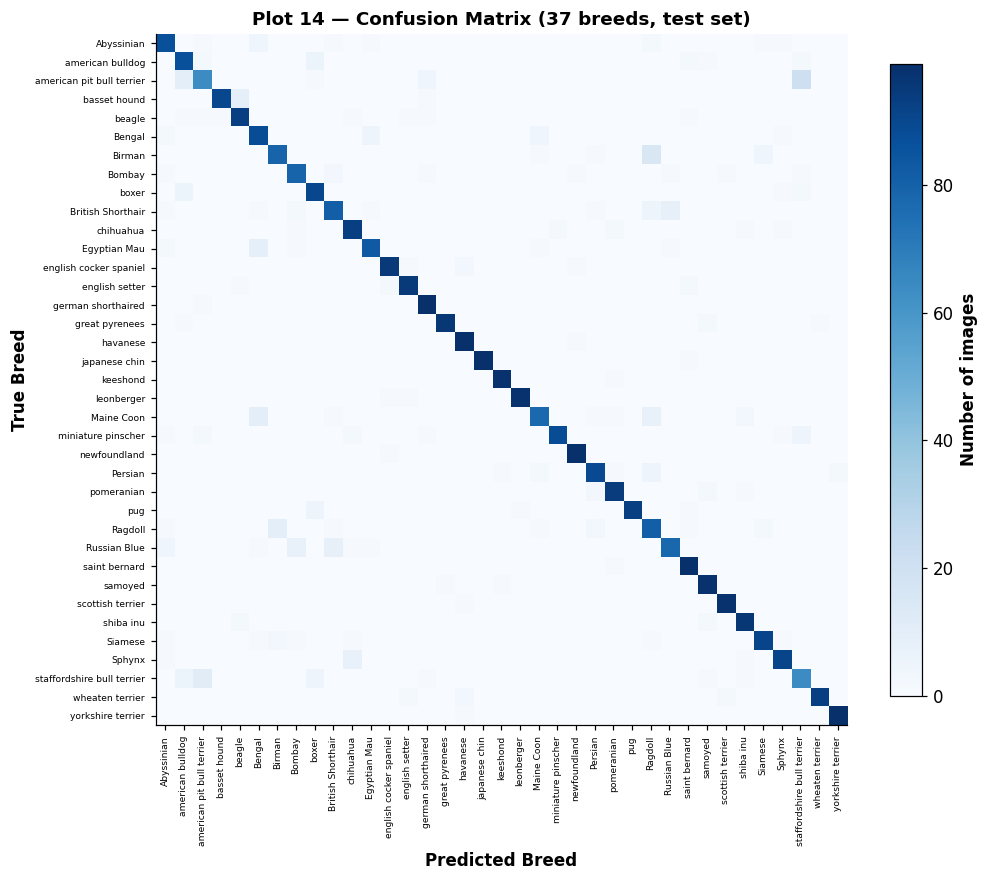


Best and worst classified breeds
------------------------------------------------------------------
Rank     Breed                       Per-class Accuracy %  Support
------------------------------------------------------------------
best 1   yorkshire terrier           99.0                  100    
best 2   newfoundland                99.0                  100    
best 3   havanese                    99.0                  100    
best 4   japanese chin               99.0                  100    
best 5   saint bernard               99.0                  100    
worst 1  american pit bull terrier   64.0                  100    
worst 2  staffordshire bull terrier  71.9                  89     
worst 3  Maine Coon                  77.0                  100    
worst 4  Russian Blue                78.0                  100    
worst 5  Birman                      79.0                  100    
------------------------------------------------------------------

Most frequently confused br

In [ ]:
# ===================== CELL 17 — Plot 14: confusion matrix =====================
cm = confusion_matrix(yte, pred)
fig, ax = plt.subplots(figsize=(9.5, 8.5))
im = ax.imshow(cm, cmap='Blues', interpolation='nearest')
ax.set_xticks(range(N_CLASSES)); ax.set_yticks(range(N_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=6)
ax.set_yticklabels(CLASS_NAMES, fontsize=6)
ax.set_xlabel('Predicted Breed'); ax.set_ylabel('True Breed')
ax.set_title('Plot 14 — Confusion Matrix (37 breeds, test set)')
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8, label='Number of images')
save(fig, 'plot14_confusion_matrix')

per_class = cm.diagonal() / cm.sum(1)
order = np.argsort(per_class)
table('Best and worst classified breeds',
      ['Rank', 'Breed', 'Per-class Accuracy %', 'Support'],
      [[f'best {i+1}', CLASS_NAMES[j], f'{100*per_class[j]:.1f}', cm.sum(1)[j]]
       for i, j in enumerate(order[::-1][:5])] +
      [[f'worst {i+1}', CLASS_NAMES[j], f'{100*per_class[j]:.1f}', cm.sum(1)[j]]
       for i, j in enumerate(order[:5])])

off = cm.copy(); np.fill_diagonal(off, 0)
pairs = np.dstack(np.unravel_index(np.argsort(off.ravel())[::-1][:8], off.shape))[0]
table('Most frequently confused breed pairs',
      ['True Breed', 'Predicted As', 'Count'],
      [[CLASS_NAMES[a], CLASS_NAMES[b], off[a, b]] for a, b in pairs])

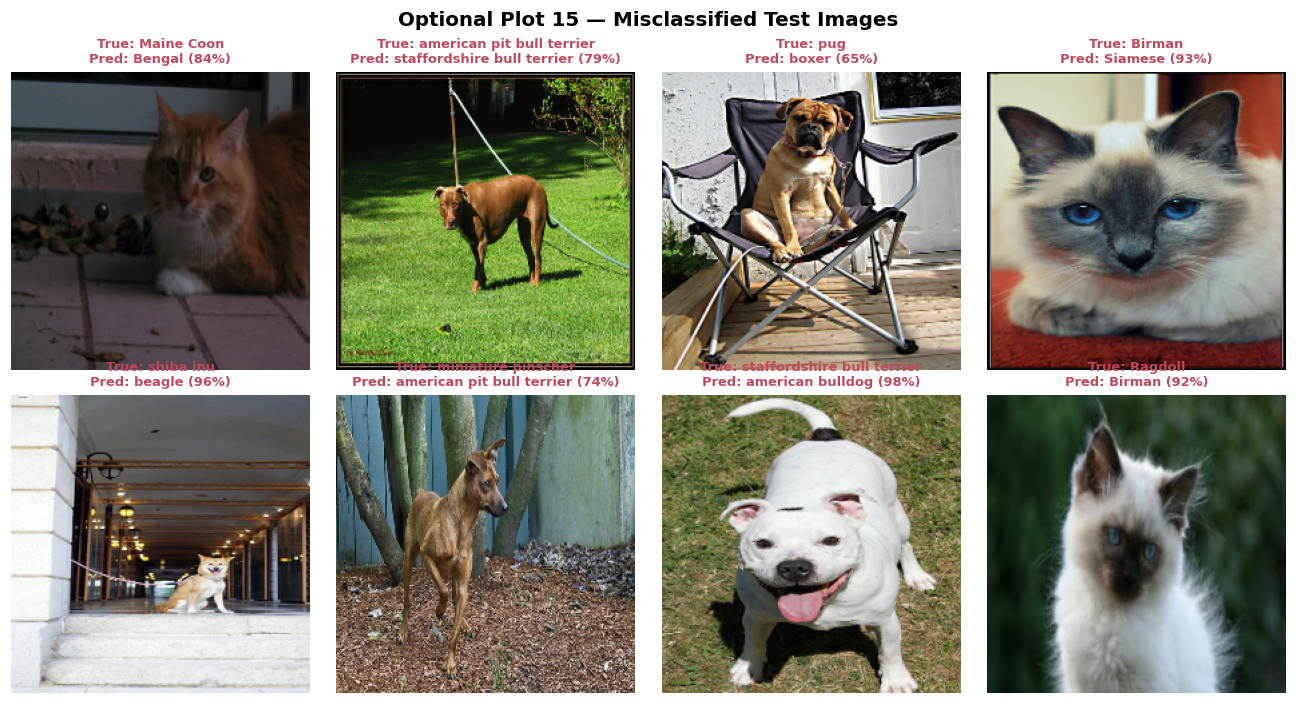

Typical visual reasons: near-identical coat colour and markings between the true and
predicted breed, the animal occupying a small part of the frame, unusual pose or heavy
occlusion, and lighting that washes out the fine texture cues the network relies on.


In [ ]:
# ===================== CELL 18 — Optional Plot 15: misclassified images =====================
wrong = np.where(pred != yte)[0][:8]
want = {int(i) for i in wrong}
imgs = {}
for i, (im_, lb) in enumerate(raw_test.as_numpy_iterator()):
    if i in want:
        imgs[i] = tf.image.resize(im_, (IMG_SIZE, IMG_SIZE)).numpy().astype('uint8')
    if len(imgs) == len(want):
        break

fig, axes = plt.subplots(2, 4, figsize=(12, 6.5))
for ax in axes.ravel():
    ax.axis('off')
for ax, i in zip(axes.ravel(), wrong):
    ax.imshow(imgs[int(i)])
    ax.set_title(f'True: {CLASS_NAMES[yte[i]]}\nPred: {CLASS_NAMES[pred[i]]} '
                 f'({100*proba[i].max():.0f}%)', fontsize=8.5, color=C[1])
fig.suptitle('Optional Plot 15 — Misclassified Test Images', fontweight='bold', fontsize=13)
save(fig, 'plot15_misclassified')

print('Typical visual reasons: near-identical coat colour and markings between the true and')
print('predicted breed, the animal occupying a small part of the frame, unusual pose or heavy')
print('occlusion, and lighting that washes out the fine texture cues the network relies on.')

In [ ]:
# ===================== CELL 19 — Section 13: overall results =====================
print('Cross-validating the remaining rows...')
get_cv('Baseline', BASE)
get_cv('Best Initialization', CFG_INIT)
get_cv('Best Regularization', CFG_REG)
get_cv('Best Optimizer', CFG_OPT)
get_cv('Best Hyperparameters', CFG_TUNED)

OVERALL = [('Baseline', BASE), ('Best Initialization', CFG_INIT),
           ('Best Regularization', CFG_REG), ('Best Optimizer', CFG_OPT),
           ('Best Hyperparameters', CFG_TUNED)]

rows = []
for name, cfg in OVERALL:
    a, _ = CV[name]
    _, ta, tt = fit_and_test(cfg)
    rows.append([name, f'{a.mean():.2f}', f'{a.std():.2f}', f'{ta:.2f}', f'{tt:.1f}'])
rows.append(['Fine-Tuned Model', 'not run', '-', f'{acc_ft_best:.2f}', f'{t_ft_best:.0f}'])

table('Overall Results (Section 13 table) - accuracy in %, time in seconds',
      ['Configuration', 'CV Accuracy', 'SD', 'Test Accuracy', 'Training Time'], rows)

print('Notes:')
print(' - Rows 1-5 train only the classifier head on cached frozen features, so their training')
print('   times exclude the one-off feature-extraction pass reported in Cell 4.')
print(' - The fine-tuned row uses the validation-selected configuration from Cell 14, and its')
print('   training time includes the shared 8-epoch warm-up, so it is comparable to Case A.')
print(f' - 5-fold CV was not run for fine-tuning: five folds would cost roughly '
      f'{5*t_ft_best/60:.0f} minutes')
print('   against a few seconds per fold for the head-only rows. That cost gap is itself part of')
print('   the justification the manual asks for.')

Cross-validating the remaining rows...
  Baseline                 91.96 +/- 1.03 %  (57s)
  Best Initialization      91.39 +/- 1.39 %  (55s)
  Best Regularization      90.14 +/- 1.78 %  (56s)
  Best Optimizer           88.97 +/- 0.78 %  (54s)
  Best Hyperparameters     91.47 +/- 0.80 %  (94s)

Overall Results (Section 13 table) - accuracy in %, time in seconds
---------------------------------------------------------------------
Configuration         CV Accuracy  SD    Test Accuracy  Training Time
---------------------------------------------------------------------
Baseline              91.96        1.03  90.52          9.6          
Best Initialization   91.39        1.39  90.13          9.5          
Best Regularization   90.14        1.78  88.09          9.3          
Best Optimizer        88.97        0.78  88.55          8.7          
Best Hyperparameters  91.47        0.80  90.43          17.3         
Fine-Tuned Model      not run      -     89.37          310          
-------

In [ ]:
# ===================== CELL 20 — final model justification =====================
best_head = max(OVERALL, key=lambda kv: CV[kv[0]][0].mean())[0]
spread = max(CV[n][0].mean() for n, _ in OVERALL) - min(CV[n][0].mean() for n, _ in OVERALL)
mean_sd = float(np.mean([CV[n][0].std() for n, _ in OVERALL]))

print(f'Best head-only configuration by CV : {best_head}  '
      f'({CV[best_head][0].mean():.2f} +/- {CV[best_head][0].std():.2f} %)')
print(f'Case A feature extraction          : test {acc_fe:.2f} %  ({t_fe:.0f}s)')
print(f'Best fine-tuned model              : test {acc_ft_best:.2f} %  ({t_ft_best:.0f}s)')
print()
print(f'Spread across all head configurations : {spread:.2f} %')
print(f'Average cross-validation SD           : {mean_sd:.2f} %')
if spread < mean_sd:
    print('=> The spread is SMALLER than the average fold-to-fold SD, so the head-only')
    print('   configurations are statistically indistinguishable. Frozen ImageNet features are')
    print('   already near-linearly separable for these 37 breeds, so the classifier saturates')
    print('   regardless of initialization, regularizer or optimizer. This is the direct answer')
    print('   to discussion question 23.')
else:
    print('=> The spread exceeds the average SD, so the ranking of configurations is meaningful.')
print()
print('Justification criteria required by the manual:')
print(' - Accuracy       : compare the Test Accuracy column above.')
print(' - Variability    : prefer a small CV standard deviation; a large SD means the result')
print('                    depends on which images landed in the validation fold.')
print(' - Computational  : head-only training is seconds after one feature pass; fine-tuning')
print('                    needs a full backward pass through the base every epoch.')
print(' - Generalization : a small gap between mean CV accuracy and test accuracy indicates the')
print('                    configuration was not over-selected on the validation folds.')

Best head-only configuration by CV : Baseline  (91.96 +/- 1.03 %)
Case A feature extraction          : test 88.93 %  (393s)
Best fine-tuned model              : test 89.37 %  (310s)

Spread across all head configurations : 2.99 %
Average cross-validation SD           : 1.16 %
=> The spread exceeds the average SD, so the ranking of configurations is meaningful.

Justification criteria required by the manual:
 - Accuracy       : compare the Test Accuracy column above.
 - Variability    : prefer a small CV standard deviation; a large SD means the result
                    depends on which images landed in the validation fold.
 - Computational  : head-only training is seconds after one feature pass; fine-tuning
                    needs a full backward pass through the base every epoch.
 - Generalization : a small gap between mean CV accuracy and test accuracy indicates the
                    configuration was not over-selected on the validation folds.


Cross-validating the new combinations...
  N1                       91.41 +/- 1.08 %  (97s)
  N2                       91.33 +/- 1.33 %  (46s)

Additional exercise - new combinations vs the selected configuration
------------------------------------------------------------------------------------------------------
Configuration            Fine-tuning strategy  CV Accuracy %  SD %  Test Accuracy %  Training Time (s)
------------------------------------------------------------------------------------------------------
C1 Baseline (selected)   frozen base           91.96          1.03  90.52            9.8              
N1                       frozen base           91.41          1.08  90.38            17.4             
N2                       frozen base + BN/L2   91.33          1.33  89.21            7.9              
FT lr=1e-05, layer 140+  partial unfreezing    not run        -     89.37            310              
------------------------------------------------------------------

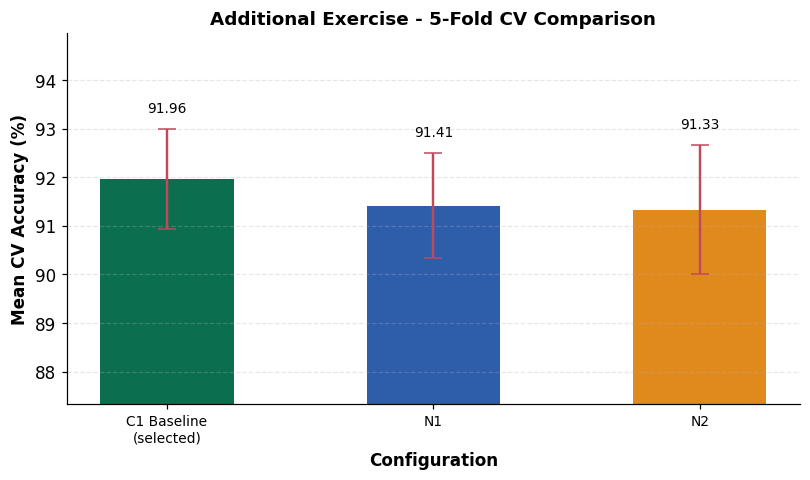


Highest mean CV accuracy: C1 Baseline (selected) (91.96 +/- 1.03 %)
Margin over N1: 0.54 %, against an SD of 1.03 %.
A new configuration is preferable only if its margin exceeds the standard deviations AND
its test accuracy and training cost are no worse.


In [ ]:
# ===================== CELL 21 — Section 16: additional exercise =====================
N1 = {**BASE, 'init': best_init, 'lr': 1e-4, 'dropout': 0.25, 'bs': 16}
N2 = {**BASE, 'init': best_init, 'lr': 1e-3, 'dropout': 0.50, 'bs': 64, 'bn': True, 'l2': 1e-4}

print('Cross-validating the new combinations...')
get_cv('N1', N1)
get_cv('N2', N2)

new_rows, comp = [], {}
for name, cfg in [(f'{BEST_NAME} (selected)', BEST_CFG), ('N1', N1), ('N2', N2)]:
    key = BEST_NAME if '(selected)' in name else name
    a, _ = CV[key]
    _, ta, tt = fit_and_test(cfg)
    strategy = 'frozen base + BN/L2' if name == 'N2' else 'frozen base'
    new_rows.append([name, strategy, f'{a.mean():.2f}', f'{a.std():.2f}', f'{ta:.2f}', f'{tt:.1f}'])
    comp[name] = (a.mean(), a.std())
new_rows.append([f'FT lr={BEST_FT[0]:g}, layer {BEST_FT[1]}+', 'partial unfreezing',
                 'not run', '-', f'{acc_ft_best:.2f}', f'{t_ft_best:.0f}'])

table('Additional exercise - new combinations vs the selected configuration',
      ['Configuration', 'Fine-tuning strategy', 'CV Accuracy %', 'SD %',
       'Test Accuracy %', 'Training Time (s)'], new_rows)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ks = list(comp)
b = ax.bar(range(len(ks)), [comp[k][0] for k in ks], yerr=[comp[k][1] for k in ks],
           capsize=6, color=[C[0], C[2], C[3]], width=0.5, error_kw=dict(ecolor=C[1], lw=1.6))
ax.bar_label(b, fmt='%.2f', padding=9, fontsize=9)
ax.set_xticks(range(len(ks)))
ax.set_xticklabels([k.replace(' (selected)', '\n(selected)') for k in ks], fontsize=9)
ax.set_ylim(min(comp[k][0] for k in ks) - 4, max(comp[k][0] for k in ks) + 3)
ax.set_xlabel('Configuration'); ax.set_ylabel('Mean CV Accuracy (%)')
ax.set_title('Additional Exercise - 5-Fold CV Comparison')
ax.grid(axis='x', visible=False)
save(fig, 'plot16_additional_exercise')

win = max(comp, key=lambda k: comp[k][0])
runner = max((k for k in comp if k != win), key=lambda k: comp[k][0])
margin = comp[win][0] - comp[runner][0]
print(f'\nHighest mean CV accuracy: {win} ({comp[win][0]:.2f} +/- {comp[win][1]:.2f} %)')
print(f'Margin over {runner}: {margin:.2f} %, against an SD of {comp[win][1]:.2f} %.')
print('A new configuration is preferable only if its margin exceeds the standard deviations AND')
print('its test accuracy and training cost are no worse.')